# Multipole Moment Comparison for Various Ion Trap Geometries
This notebook replicates Table 3.2 by computing multipole moment ratios (p_n/p_2) for 8 different trap geometries.


In [ ]:
# ========================= 
# Imports & Setup
# =========================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

# Pseudopotential transformation for accurate multipole extraction
from multipole_pseudopotential import (
    compute_pseudopotential,
    ION_MASS, RF_OMEGA, RF_VOLTAGE
)

sns.set_theme(style="whitegrid")
%matplotlib inline

print(f"✓ Pseudopotential module loaded")
print(f"  Ion: ¹⁷¹Yb⁺, RF: {RF_VOLTAGE}V @ {RF_OMEGA/(2*np.pi*1e6):.1f} MHz")


In [2]:
# =========================
# Core Functions
# =========================

def create_rectangular_electrode_mask(cx, cy, width, height, X, Y):
    """Create a rectangular electrode mask."""
    x1 = cx - width / 2
    x2 = cx + width / 2
    y1 = cy - height / 2
    y2 = cy + height / 2
    mask = (X >= x1) & (X <= x2) & (Y >= y1) & (Y <= y2)
    return mask

def create_circular_electrode_mask(cx, cy, radius, X, Y):
    """Create a circular electrode mask."""
    dist_from_center = np.sqrt((X - cx)**2 + (Y - cy)**2)
    mask = dist_from_center <= radius
    return mask

def solve_potential(nx, ny, electrodes, fixed, V, max_iter=3000, tol=1e-3):
    """Solve Laplace equation using relaxation method."""
    for it in tqdm(range(max_iter), desc="Solving potential"):
        V_old = V.copy()
        for y in range(1, ny - 1):
            for x in range(1, nx - 1):
                if not fixed[y, x]:
                    V[y, x] = 0.25 * (V[y + 1, x] + V[y - 1, x] + V[y, x + 1] + V[y, x - 1])
        
        # Reapply fixed voltages
        for electrode in electrodes:
            mask = electrode['mask']
            V[mask] = electrode['voltage']
        
        diff = np.max(np.abs(V - V_old))
        if diff < tol:
            print(f'Converged after {it+1} iterations (diff={diff:.2e})')
            break
    else:
        print(f'Max iterations reached, diff={diff:.2e}')
    return V

def _harmonic_basis_xy(x, y, n):
    """Compute harmonic basis functions Re(z^n) and Im(z^n) where z = x + iy."""
    z = x + 1j*y
    zn = z**n
    return np.real(zn), np.imag(zn)

def fit_multipoles_2d(V, X, Y, *, r_fit_um=50.0, ion_elc_dis_um=50.0, n_max=8, exclude_mask=None):
    """
    Fit V(x,y) inside radius r_fit_um to multipole expansion:
        V ≈ sum_{n=0..n_max} (1/R^n) [ a_n Re((x+iy)^n) + b_n Im((x+iy)^n) ]
    Returns dict with a[n], b[n], p[n] = sqrt(a_n^2 + b_n^2).
    """
    x = X.ravel()
    y = Y.ravel()
    v = V.ravel()
    r = np.hypot(x, y)
    
    # Select region for fitting
    region = (r <= r_fit_um)
    if exclude_mask is not None:
        region &= ~exclude_mask.ravel()
    
    x_sel, y_sel, v_sel = x[region], y[region], v[region]
    
    # Build design matrix
    cols = []
    for n in range(n_max + 1):
        Re, Im = _harmonic_basis_xy(x_sel, y_sel, n)
        scale = ion_elc_dis_um**(-n)
        cols.append(scale * Re)
        cols.append(scale * Im)
    A = np.vstack(cols).T
    
    # Least squares fit
    coeffs, *_ = np.linalg.lstsq(A, v_sel, rcond=None)
    
    a, b, p = {}, {}, {}
    for n in range(n_max + 1):
        a[n] = float(coeffs[2*n])
        b[n] = float(coeffs[2*n + 1])
        p[n] = float(np.hypot(a[n], b[n]))
    
    return {"a": a, "b": b, "p": p}

def multipole_ratio_row(p_dict, base_n=2, max_n=8):
    """Build a dict of ratios p_n/p_base for n=3..max_n."""
    p2 = p_dict.get(base_n, np.nan)
    row = {}
    for n in range(3, max_n + 1):
        ratio = (p_dict.get(n, np.nan) / p2) if (p2 and not np.isnan(p2) and p2 != 0) else np.nan
        row[f"p{n}/p{base_n}"] = ratio
    return row

def plot_potential(V, X, Y, electrodes, title="Electric Potential"):
    """Plot the electric potential."""
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(V, extent=[X.min(), X.max(), Y.min(), Y.max()], 
                   origin='lower', cmap='viridis')
    fig.colorbar(im, ax=ax, label='Potential (V)')
    ax.set_title(title)
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_aspect('equal')
    
    # Draw electrode outlines
    for e in electrodes:
        ax.contour(X, Y, e['mask'].astype(float), levels=[0.5], 
                   colors='red', linewidths=1.5)
    
    plt.tight_layout()
    plt.show()


In [3]:
# =========================
# Trap Geometry Builders
# =========================

def build_trap_a_2layer(X, Y):
    """
    Trap (a): 2-layer
    - Four electrodes: 2 on top, 2 on bottom
    - Horizontal gap: 200 µm
    - Vertical gap: 200 µm
    - Electrode thickness: 125 µm
    - Configuration creates quadrupole: +V/-V on diagonals
    - Ion floats in center
    """
    h_gap = 200  # µm (horizontal gap between electrode inner edges)
    v_gap = 200  # µm (vertical gap between electrode inner surfaces)
    thickness = 125  # µm (electrode thickness/width)
    electrode_height = 150  # µm (electrode height)
    ion_height = 0  # µm (ion centered at origin)
    
    # Electrode center positions:
    # x: gap/2 + thickness/2 from center (so inner edges are at ±gap/2)
    # y: gap/2 + height/2 from center (so inner surfaces are at ±gap/2)
    x_pos = h_gap/2 + thickness/2  # = 162.5 µm
    y_pos = v_gap/2 + electrode_height/2  # = 175 µm (so inner surface at 100 µm)
    
    electrodes = [
        # Quadrupole configuration: opposite corners have same voltage
        # Top-left (-x, +y) and bottom-right (+x, -y): -1V
        # Top-right (+x, +y) and bottom-left (-x, -y): +1V
        {'cx': -x_pos, 'cy': y_pos, 'width': thickness, 'height': electrode_height, 
         'voltage': -1.0, 'type': 'RF-'},
        {'cx': x_pos, 'cy': y_pos, 'width': thickness, 'height': electrode_height, 
         'voltage': 1.0, 'type': 'RF+'},
        {'cx': -x_pos, 'cy': -y_pos, 'width': thickness, 'height': electrode_height, 
         'voltage': 1.0, 'type': 'RF+'},
        {'cx': x_pos, 'cy': -y_pos, 'width': thickness, 'height': electrode_height, 
         'voltage': -1.0, 'type': 'RF-'},
    ]
    
    return electrodes, ion_height

def build_trap_b_balanced_2layer(X, Y):
    """
    Trap (b): Balanced 2-layer
    - Vertical gap: 220 µm (between electrode inner surfaces)
    - Horizontal gap: 200 µm (between electrode inner edges)
    - Electrode thickness: 125 µm
    - Configuration creates quadrupole: +V/-V on diagonals
    - Ion floats in center
    """
    h_gap = 200  # µm (horizontal gap between inner edges)
    v_gap = 220  # µm (vertical gap between inner surfaces)
    thickness = 125  # µm (electrode width)
    electrode_height = 150  # µm
    ion_height = 0  # µm (ion centered at origin)
    
    # Electrode center positions
    x_pos = h_gap/2 + thickness/2  # = 162.5 µm
    y_pos = v_gap/2 + electrode_height/2  # = 185 µm (inner surface at 110 µm)
    
    electrodes = [
        # Quadrupole configuration: opposite corners have same voltage
        {'cx': -x_pos, 'cy': y_pos, 'width': thickness, 'height': electrode_height, 
         'voltage': -1.0, 'type': 'RF-'},
        {'cx': x_pos, 'cy': y_pos, 'width': thickness, 'height': electrode_height, 
         'voltage': 1.0, 'type': 'RF+'},
        {'cx': -x_pos, 'cy': -y_pos, 'width': thickness, 'height': electrode_height, 
         'voltage': 1.0, 'type': 'RF+'},
        {'cx': x_pos, 'cy': -y_pos, 'width': thickness, 'height': electrode_height, 
         'voltage': -1.0, 'type': 'RF-'},
    ]
    
    return electrodes, ion_height

def build_trap_c_3layer(X, Y):
    """
    Trap (c): 3-layer linear Paul trap
    - Simulated as 4-electrode quadrupole to represent pseudopotential
    - Top/bottom at one polarity, left/right at opposite polarity
    - This creates the saddle-point potential that the real trap's pseudopotential produces
    - Geometry: 125 µm vertical spacing, 200 µm horizontal gap
    """
    h_gap = 200  # µm (horizontal gap)
    v_gap = 250  # µm (vertical gap - 125 µm to each ground plane)
    rf_thickness = 125  # µm
    ion_height = 0  # µm (centered)
    
    electrode_height = 100  # µm
    
    electrodes = [
        # Top electrode (represents top ground plane effect)
        {'cx': 0, 'cy': v_gap/2, 'width': 300, 'height': electrode_height, 
         'voltage': 1.0, 'type': 'V+'},
        # Bottom electrode (represents bottom ground plane effect)
        {'cx': 0, 'cy': -v_gap/2, 'width': 300, 'height': electrode_height, 
         'voltage': 1.0, 'type': 'V+'},
        # Left RF electrode
        {'cx': -h_gap/2 - rf_thickness/2, 'cy': 0, 'width': rf_thickness, 'height': 150, 
         'voltage': -1.0, 'type': 'V-'},
        # Right RF electrode
        {'cx': h_gap/2 + rf_thickness/2, 'cy': 0, 'width': rf_thickness, 'height': 150, 
         'voltage': -1.0, 'type': 'V-'},
    ]
    
    return electrodes, ion_height


In [4]:
def build_trap_d_algaas(X, Y):
    """
    Trap (d): GaAs/AlGaAs 2-layer surface trap (Stick '06)
    - Two stacked HORIZONTAL electrodes on each side
    - Each electrode: ~10 µm thick (vertical)
    - Vertical gap between stacked electrodes: 4 µm
    - Horizontal gap between left and right stacks: 60 µm
    - Left stack: G-RF (Ground top, RF bottom)
    - Right stack: RF-G (RF top, Ground bottom)
    - Ion held in center
    
    Cross-section:
        [GND]       [RF ]    <- top
              ⊙ ion
        [RF ]       [GND]    <- bottom
    """
    h_gap = 60  # µm (horizontal gap between stacks)
    v_gap = 4  # µm (vertical gap between electrodes in stack)
    thickness = 10  # µm (electrode thickness, slightly larger than 8.6 for grid)
    electrode_width = 50  # µm (horizontal width)
    ion_height = 0  # µm (ion at origin)
    
    # X positions of electrode stacks
    x_left = -(h_gap/2 + electrode_width/2)   # -55 µm
    x_right = (h_gap/2 + electrode_width/2)   # +55 µm
    
    # Y positions (centered around origin)
    y_top = v_gap/2 + thickness/2      # +7 µm
    y_bottom = -(v_gap/2 + thickness/2) # -7 µm
    
    electrodes = [
        # Left stack: G-RF
        {'cx': x_left, 'cy': y_top, 'width': electrode_width, 'height': thickness,
         'voltage': 0.0, 'type': 'GND'},
        {'cx': x_left, 'cy': y_bottom, 'width': electrode_width, 'height': thickness,
         'voltage': 1.0, 'type': 'RF'},
        # Right stack: RF-G
        {'cx': x_right, 'cy': y_top, 'width': electrode_width, 'height': thickness,
         'voltage': 1.0, 'type': 'RF'},
        {'cx': x_right, 'cy': y_bottom, 'width': electrode_width, 'height': thickness,
         'voltage': 0.0, 'type': 'GND'},
    ]
    
    return electrodes, ion_height

def build_trap_e_inplane_4wire(X, Y):
    """
    Trap (e): In-plane 4-wire trap
    - All electrodes in single horizontal plane
    - All electrodes: 20 µm thick
    - Ground electrodes on outside, RF in center
    - Distance between RF electrodes: 80 µm
    - Ion levitates at 40 µm above plane
    """
    rf_gap = 80  # µm
    thickness = 20  # µm
    ion_height = 40  # µm
    plane_y = 0  # µm
    
    rf_width = 60  # µm (RF electrodes smaller)
    gnd_width = 100  # µm (ground electrodes larger)
    
    electrodes = [
        # Outer ground electrodes
        {'cx': -rf_gap/2 - rf_width/2 - gnd_width/2, 'cy': plane_y, 'width': gnd_width, 'height': thickness, 
         'voltage': 0.0, 'type': 'GND'},
        {'cx': rf_gap/2 + rf_width/2 + gnd_width/2, 'cy': plane_y, 'width': gnd_width, 'height': thickness, 
         'voltage': 0.0, 'type': 'GND'},
        # Inner RF electrodes
        {'cx': -rf_gap/2, 'cy': plane_y, 'width': rf_width, 'height': thickness, 
         'voltage': 1.0, 'type': 'RF+'},
        {'cx': rf_gap/2, 'cy': plane_y, 'width': rf_width, 'height': thickness, 
         'voltage': -1.0, 'type': 'RF-'},
    ]
    
    return electrodes, ion_height

def build_trap_f_4wire_surface(X, Y):
    """
    Trap (f): 4-wire surface trap (DC-RF-DC-RF)
    - Planar variant: longer ground, 40 µm RF, 40 µm ground, longer RF
    - Ion height: 40 µm
    """
    ion_height = 40  # µm
    plane_y = 0  # µm
    electrode_thickness = 20  # µm
    
    gnd_width = 40  # µm
    rf_width = 40  # µm
    long_gnd_width = 80  # µm
    long_rf_width = 80  # µm
    
    # Layout from left to right: Long GND - RF - GND - Long RF
    spacing = 10  # µm between electrodes
    x_pos = -(long_gnd_width + rf_width + gnd_width + long_rf_width)/2 - 1.5*spacing
    
    electrodes = [
        # Long ground (left)
        {'cx': x_pos + long_gnd_width/2, 'cy': plane_y, 'width': long_gnd_width, 'height': electrode_thickness, 
         'voltage': 0.0, 'type': 'GND'},
        # RF
        {'cx': x_pos + long_gnd_width + spacing + rf_width/2, 'cy': plane_y, 'width': rf_width, 'height': electrode_thickness, 
         'voltage': 1.0, 'type': 'RF+'},
        # Ground
        {'cx': x_pos + long_gnd_width + spacing + rf_width + spacing + gnd_width/2, 'cy': plane_y, 
         'width': gnd_width, 'height': electrode_thickness, 'voltage': 0.0, 'type': 'GND'},
        # Long RF (right)
        {'cx': x_pos + long_gnd_width + spacing + rf_width + spacing + gnd_width + spacing + long_rf_width/2, 
         'cy': plane_y, 'width': long_rf_width, 'height': electrode_thickness, 
         'voltage': -1.0, 'type': 'RF-'},
    ]
    
    return electrodes, ion_height


In [5]:
def build_trap_g_5wire_symmetric(X, Y):
    """
    Trap (g): Symmetric 5-wire surface trap (DC-RF-DC-RF-DC)
    - Electrode widths: 40 µm each except outer grounds (longer)
    - Ion at 40 µm above central DC
    """
    ion_height = 40  # µm
    plane_y = 0  # µm
    electrode_thickness = 20  # µm
    
    center_width = 40  # µm
    outer_width = 80  # µm
    spacing = 10  # µm
    
    # Layout: Outer GND - RF - Central GND - RF - Outer GND
    total_width = 2*outer_width + 2*center_width + center_width + 4*spacing
    x_start = -total_width/2
    
    electrodes = [
        # Left outer ground
        {'cx': x_start + outer_width/2, 'cy': plane_y, 'width': outer_width, 'height': electrode_thickness, 
         'voltage': 0.0, 'type': 'GND'},
        # Left RF
        {'cx': x_start + outer_width + spacing + center_width/2, 'cy': plane_y, 
         'width': center_width, 'height': electrode_thickness, 'voltage': 1.0, 'type': 'RF+'},
        # Central ground
        {'cx': x_start + outer_width + spacing + center_width + spacing + center_width/2, 'cy': plane_y, 
         'width': center_width, 'height': electrode_thickness, 'voltage': 0.0, 'type': 'GND'},
        # Right RF
        {'cx': x_start + outer_width + spacing + center_width + spacing + center_width + spacing + center_width/2, 
         'cy': plane_y, 'width': center_width, 'height': electrode_thickness, 
         'voltage': -1.0, 'type': 'RF-'},
        # Right outer ground
        {'cx': x_start + outer_width + spacing + center_width + spacing + center_width + spacing + center_width + spacing + outer_width/2, 
         'cy': plane_y, 'width': outer_width, 'height': electrode_thickness, 
         'voltage': 0.0, 'type': 'GND'},
    ]
    
    return electrodes, ion_height

def build_trap_h_5wire_asymmetric(X, Y):
    """
    Trap (h): Asymmetric 5-wire surface trap
    - Same as (g) but right RF is 36 µm, left RF is 44 µm
    - Ion height: 40 µm
    """
    ion_height = 40  # µm
    plane_y = 0  # µm
    electrode_thickness = 20  # µm
    
    center_width = 40  # µm
    outer_width = 80  # µm
    left_rf_width = 44  # µm
    right_rf_width = 36  # µm
    spacing = 10  # µm
    
    total_width = 2*outer_width + left_rf_width + right_rf_width + center_width + 4*spacing
    x_start = -total_width/2
    
    electrodes = [
        # Left outer ground
        {'cx': x_start + outer_width/2, 'cy': plane_y, 'width': outer_width, 'height': electrode_thickness, 
         'voltage': 0.0, 'type': 'GND'},
        # Left RF (44 µm)
        {'cx': x_start + outer_width + spacing + left_rf_width/2, 'cy': plane_y, 
         'width': left_rf_width, 'height': electrode_thickness, 'voltage': 1.0, 'type': 'RF+'},
        # Central ground
        {'cx': x_start + outer_width + spacing + left_rf_width + spacing + center_width/2, 'cy': plane_y, 
         'width': center_width, 'height': electrode_thickness, 'voltage': 0.0, 'type': 'GND'},
        # Right RF (36 µm)
        {'cx': x_start + outer_width + spacing + left_rf_width + spacing + center_width + spacing + right_rf_width/2, 
         'cy': plane_y, 'width': right_rf_width, 'height': electrode_thickness, 
         'voltage': -1.0, 'type': 'RF-'},
        # Right outer ground
        {'cx': x_start + outer_width + spacing + left_rf_width + spacing + center_width + spacing + right_rf_width + spacing + outer_width/2, 
         'cy': plane_y, 'width': outer_width, 'height': electrode_thickness, 
         'voltage': 0.0, 'type': 'GND'},
    ]
    
    return electrodes, ion_height


In [ ]:
# =========================
# Simulation Function
# =========================

def simulate_trap(trap_builder, trap_name, grid_size=101, domain_scale=1.0, 
                  max_iter=3000, plot=True):
    """
    Simulate a trap geometry and extract multipole moments.
    
    Parameters:
    -----------
    trap_builder : function
        Function that returns (electrodes_list, ion_height)
    trap_name : str
        Name of the trap for plotting
    grid_size : int
        Number of grid points (default 401 for high accuracy)
    domain_scale : float
        Scale factor for domain size relative to electrode geometry
    max_iter : int
        Maximum iterations for solver (default 10000)
    plot : bool
        Whether to plot the potential
    
    Returns:
    --------
    dict : Multipole ratios p_n/p_2
    """
    print(f"\n{'='*60}")
    print(f"Simulating: {trap_name}")
    print(f"{'='*60}")
    
    # Create grid
    nx, ny = grid_size, grid_size
    
    # Determine domain size based on trap type
    # Create temporary grid to get electrode positions
    x_temp = np.linspace(-500, 500, 10)
    y_temp = np.linspace(-500, 500, 10)
    X_temp, Y_temp = np.meshgrid(x_temp, y_temp)
    electrodes_temp, ion_height = trap_builder(X_temp, Y_temp)
    
    # Find electrode extent
    all_x = [e['cx'] for e in electrodes_temp]
    all_y = [e['cy'] for e in electrodes_temp]
    max_extent = max(max(np.abs(all_x)), max(np.abs(all_y)))
    
    # Set domain size
    domain_size = max_extent * domain_scale + 100  # Add padding
    
    x = np.linspace(-domain_size, domain_size, nx)
    y = np.linspace(-domain_size, domain_size, ny)
    X, Y = np.meshgrid(x, y)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    
    # Build electrodes
    electrodes, ion_height = trap_builder(X, Y)
    
    # Initialize potential
    V = np.zeros((ny, nx))
    fixed = np.zeros_like(V, dtype=bool)
    
    # Create masks and set boundary conditions
    for e in electrodes:
        mask = create_rectangular_electrode_mask(e['cx'], e['cy'], e['width'], 
                                                  e['height'], X, Y)
        e['mask'] = mask
        V[mask] = e['voltage']
        fixed[mask] = True
    
    # Solve Laplace equation
    V = solve_potential(nx, ny, electrodes, fixed, V, max_iter=max_iter, tol=1e-3)
    
    # *** PSEUDOPOTENTIAL TRANSFORMATION (KEY CHANGE!) ***
    # Transform static RF potential to pseudopotential: φ_ps = (q/4mΩ²)|V_rf·∇φ|²
    # This captures the ponderomotive force and field line bending effects
    print("\n🔄 Computing RF pseudopotential...")
    V_pseudo = compute_pseudopotential(V, X, Y, V_rf=RF_VOLTAGE)
    print(f"   φ_ps range: [{np.min(V_pseudo):.3f}, {np.max(V_pseudo):.3f}] V")
    print(f"   φ_ps at ion: {V_pseudo[len(V_pseudo)//2, len(V_pseudo[0])//2]:.6f} V")
    
    # Plot if requested
    if plot:
        plot_potential(V, X, Y, electrodes, title=f"{trap_name} - Electric Potential")
    
    # Extract multipole moments
    # Shift coordinates so ion is at origin
    X_shifted = X
    Y_shifted = Y - ion_height
    
    # Create exclusion mask for electrodes
    exclude_mask = np.zeros_like(V, dtype=bool)
    for e in electrodes:
        exclude_mask |= e['mask']
    
    # Determine fitting radius based on trap geometry
    # Find minimum distance from ion (origin) to nearest electrode surface
    min_dist_to_electrode = float('inf')
    for e in electrodes:
        # Distance to electrode edges
        cx, cy = e.get('cx', 0), e.get('cy', 0)
        w, h = e.get('width', 0), e.get('height', 0)
        
        # Find closest point on electrode rectangle to origin
        closest_x = max(cx - w/2, min(0, cx + w/2))
        closest_y = max(cy - h/2, min(0, cy + h/2))
        dist = np.sqrt(closest_x**2 + closest_y**2)
        min_dist_to_electrode = min(min_dist_to_electrode, dist)
    
    # Fitting radius: fraction of distance to nearest electrode
    r_fit = min_dist_to_electrode * 0.5
    # Normalization scale R: distance to nearest electrode (characteristic length)
    ion_elc_dis = min_dist_to_electrode
    
    # Ensure reasonable minimums
    r_fit = max(r_fit, 15)
    ion_elc_dis = max(ion_elc_dis, 20)
    
    print(f"Distance to nearest electrode: {min_dist_to_electrode:.2f} µm")
    print(f"Fitting radius: {r_fit:.2f} µm")
    print(f"Normalization scale R: {ion_elc_dis:.2f} µm")
    
    # *** FIT PSEUDOPOTENTIAL (not static V!) ***
    # This is the critical change: we fit the pseudopotential which includes
    # the |∇φ|² nonlinearity that amplifies higher-order multipoles
    print("\n📊 Fitting multipole expansion to pseudopotential...")
    fit = fit_multipoles_2d(
        V_pseudo, X_shifted, Y_shifted,  # ✅ Use pseudopotential!
        r_fit_um=r_fit,
        ion_elc_dis_um=ion_elc_dis,
        n_max=8,
        exclude_mask=exclude_mask
    )
    
    # Compute ratios
    ratios = multipole_ratio_row(fit["p"], base_n=2, max_n=8)
    
    # Print results
    print(f"\nMultipole moments (|p_n|):")
    for n in range(2, 9):
        print(f"  p{n} = {fit['p'][n]:.6e}")
    
    print(f"\nMultipole ratios (p_n/p_2):")
    for key, val in ratios.items():
        print(f"  {key} = {val:.4f}")
    
    
    return ratios



Simulating: (a) 2-layer


Solving potential:   7%|▋         | 214/3000 [00:05<01:15, 36.91it/s]


Converged after 215 iterations (diff=9.99e-04)


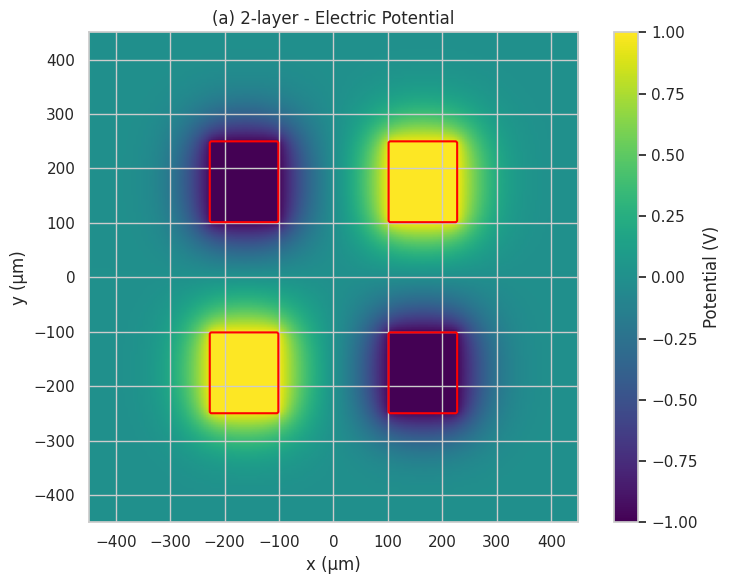

Distance to nearest electrode: 141.42 µm
Fitting radius: 70.71 µm
Normalization scale R: 141.42 µm

Multipole moments (|p_n|):
  p2 = 4.372987e-01
  p3 = 8.141230e-03
  p4 = 6.313558e-04
  p5 = 9.562540e-03
  p6 = 1.416748e-01
  p7 = 2.200790e-03
  p8 = 1.178361e-03

Multipole ratios (p_n/p_2):
  p3/p2 = 0.0186
  p4/p2 = 0.0014
  p5/p2 = 0.0219
  p6/p2 = 0.3240
  p7/p2 = 0.0050
  p8/p2 = 0.0027

Simulating: (b) Balanced 2-layer


Solving potential:   7%|▋         | 213/3000 [00:06<01:19, 34.87it/s]


Converged after 214 iterations (diff=9.96e-04)


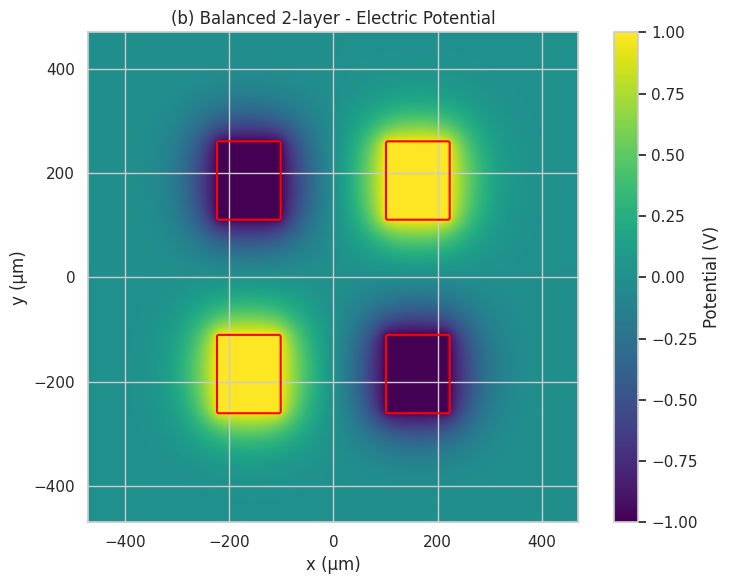

Distance to nearest electrode: 148.66 µm
Fitting radius: 74.33 µm
Normalization scale R: 148.66 µm

Multipole moments (|p_n|):
  p2 = 4.398320e-01
  p3 = 8.420478e-03
  p4 = 4.269074e-02
  p5 = 1.025310e-02
  p6 = 1.362501e-01
  p7 = 9.031649e-03
  p8 = 1.789733e-02

Multipole ratios (p_n/p_2):
  p3/p2 = 0.0191
  p4/p2 = 0.0971
  p5/p2 = 0.0233
  p6/p2 = 0.3098
  p7/p2 = 0.0205
  p8/p2 = 0.0407

Simulating: (c) 3-layer


Solving potential:   8%|▊         | 236/3000 [00:06<01:17, 35.55it/s]


Converged after 237 iterations (diff=9.95e-04)


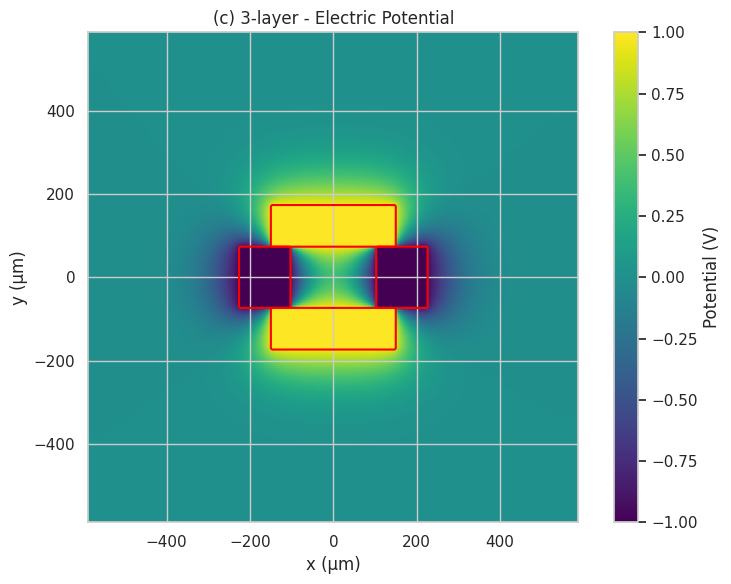

Distance to nearest electrode: 75.00 µm
Fitting radius: 37.50 µm
Normalization scale R: 75.00 µm

Multipole moments (|p_n|):
  p2 = 6.623662e-01
  p3 = 5.504457e-04
  p4 = 5.302536e-02
  p5 = 1.149900e-03
  p6 = 1.816727e-02
  p7 = 4.421028e-03
  p8 = 5.244385e-01

Multipole ratios (p_n/p_2):
  p3/p2 = 0.0008
  p4/p2 = 0.0801
  p5/p2 = 0.0017
  p6/p2 = 0.0274
  p7/p2 = 0.0067
  p8/p2 = 0.7918

Simulating: (d) 2-layer AlGaAs


Solving potential:   6%|▌         | 184/3000 [00:05<01:28, 31.94it/s]


Converged after 185 iterations (diff=9.98e-04)


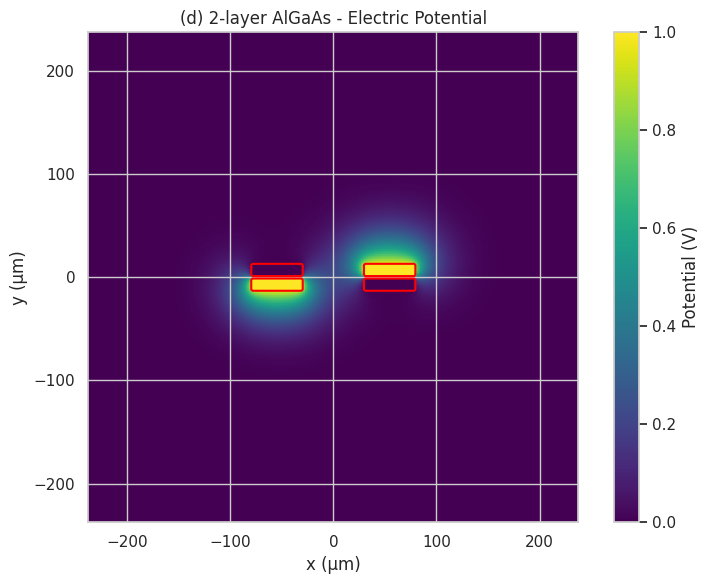

Distance to nearest electrode: 30.07 µm
Fitting radius: 15.03 µm
Normalization scale R: 30.07 µm

Multipole moments (|p_n|):
  p2 = 3.111120e-01
  p3 = 4.757243e-04
  p4 = 1.998921e-01
  p5 = 6.141018e-04
  p6 = 1.165426e-01
  p7 = 2.371583e-03
  p8 = 1.027515e+00

Multipole ratios (p_n/p_2):
  p3/p2 = 0.0015
  p4/p2 = 0.6425
  p5/p2 = 0.0020
  p6/p2 = 0.3746
  p7/p2 = 0.0076
  p8/p2 = 3.3027

Simulating: (e) In-plane 4-wire


Solving potential:   4%|▍         | 115/3000 [00:02<01:14, 38.58it/s]


Converged after 116 iterations (diff=9.98e-04)


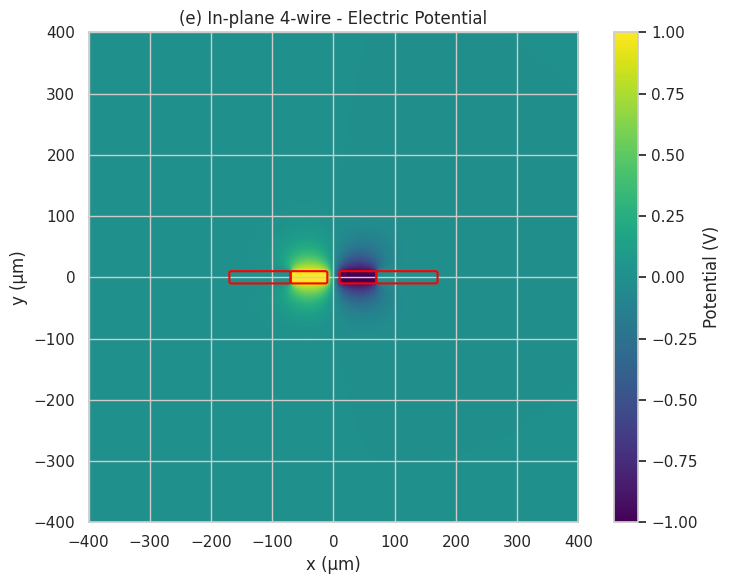

Distance to nearest electrode: 10.00 µm
Fitting radius: 15.00 µm
Normalization scale R: 20.00 µm

Multipole moments (|p_n|):
  p2 = 1.303906e-01
  p3 = 4.459960e-02
  p4 = 1.531443e-02
  p5 = 4.767989e-03
  p6 = 1.974726e-03
  p7 = 5.104685e-04
  p8 = 4.511194e-03

Multipole ratios (p_n/p_2):
  p3/p2 = 0.3420
  p4/p2 = 0.1175
  p5/p2 = 0.0366
  p6/p2 = 0.0151
  p7/p2 = 0.0039
  p8/p2 = 0.0346

Simulating: (f) 4-wire surface


Solving potential:   6%|▌         | 183/3000 [00:05<01:22, 34.19it/s]


Converged after 184 iterations (diff=1.00e-03)


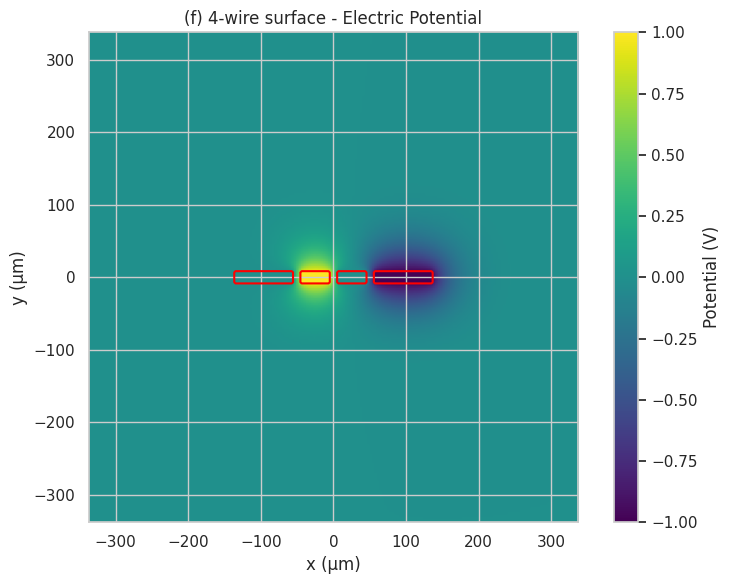

Distance to nearest electrode: 5.00 µm
Fitting radius: 15.00 µm
Normalization scale R: 20.00 µm

Multipole moments (|p_n|):
  p2 = 7.175458e-02
  p3 = 2.325676e-02
  p4 = 9.605110e-03
  p5 = 4.571654e-03
  p6 = 2.275013e-03
  p7 = 3.975345e-03
  p8 = 1.020854e-03

Multipole ratios (p_n/p_2):
  p3/p2 = 0.3241
  p4/p2 = 0.1339
  p5/p2 = 0.0637
  p6/p2 = 0.0317
  p7/p2 = 0.0554
  p8/p2 = 0.0142

Simulating: (g) 5-wire symm. surface


Solving potential:   4%|▎         | 108/3000 [00:03<01:31, 31.64it/s]


Converged after 109 iterations (diff=9.92e-04)


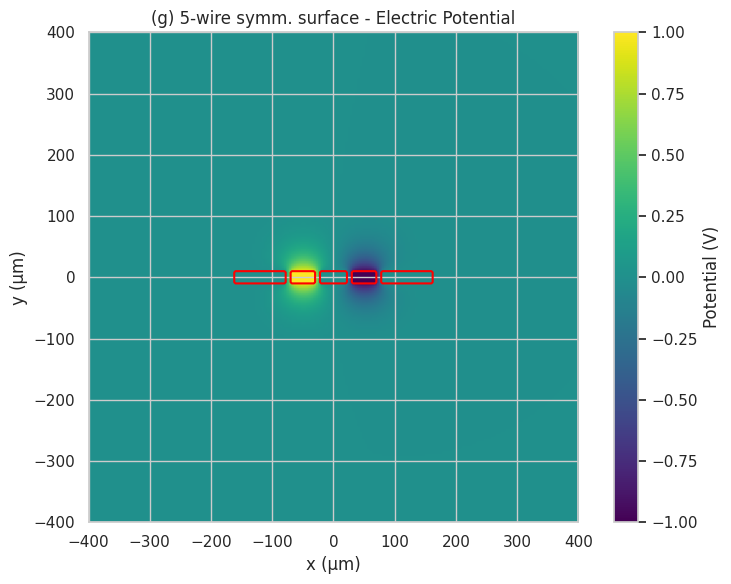

Distance to nearest electrode: 0.00 µm
Fitting radius: 15.00 µm
Normalization scale R: 20.00 µm

Multipole moments (|p_n|):
  p2 = 3.575913e-02
  p3 = 5.875683e-03
  p4 = 7.563551e-03
  p5 = 4.114759e-03
  p6 = 7.533233e-04
  p7 = 1.760734e-04
  p8 = 3.683567e-03

Multipole ratios (p_n/p_2):
  p3/p2 = 0.1643
  p4/p2 = 0.2115
  p5/p2 = 0.1151
  p6/p2 = 0.0211
  p7/p2 = 0.0049
  p8/p2 = 0.1030

Simulating: (h) 5-wire asymm. surface


Solving potential:   4%|▍         | 114/3000 [00:03<01:28, 32.76it/s]


Converged after 115 iterations (diff=9.87e-04)


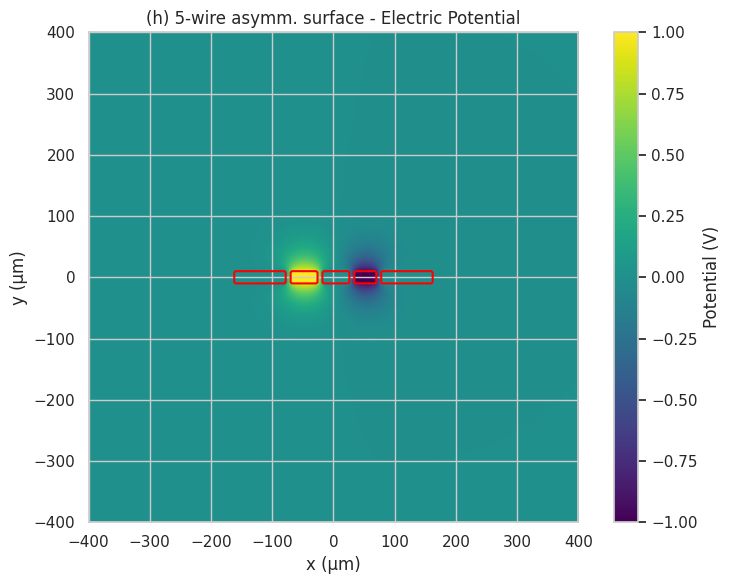

Distance to nearest electrode: 0.00 µm
Fitting radius: 15.00 µm
Normalization scale R: 20.00 µm

Multipole moments (|p_n|):
  p2 = 3.771953e-02
  p3 = 7.731959e-03
  p4 = 7.909694e-03
  p5 = 4.153920e-03
  p6 = 9.065840e-04
  p7 = 1.821590e-04
  p8 = 1.723063e-03

Multipole ratios (p_n/p_2):
  p3/p2 = 0.2050
  p4/p2 = 0.2097
  p5/p2 = 0.1101
  p6/p2 = 0.0240
  p7/p2 = 0.0048
  p8/p2 = 0.0457


In [7]:
# =========================
# Run All Simulations
# =========================

# Define all trap configurations
trap_configs = [
    (build_trap_a_2layer, "(a) 2-layer", 2.0),
    (build_trap_b_balanced_2layer, "(b) Balanced 2-layer", 2.0),
    (build_trap_c_3layer, "(c) 3-layer", 3.0),
    (build_trap_d_algaas, "(d) 2-layer AlGaAs", 2.5),
    (build_trap_e_inplane_4wire, "(e) In-plane 4-wire", 2.5),
    (build_trap_f_4wire_surface, "(f) 4-wire surface", 2.5),
    (build_trap_g_5wire_symmetric, "(g) 5-wire symm. surface", 2.5),
    (build_trap_h_5wire_asymmetric, "(h) 5-wire asymm. surface", 2.5),
]

# Store results
results = {}

# Simulate each trap
for trap_builder, trap_name, scale in trap_configs:
    try:
        ratios = simulate_trap(
            trap_builder, 
            trap_name, 
            grid_size=201,
            domain_scale=scale,
            max_iter=3000,
            plot=True
        )
        results[trap_name] = ratios
    except Exception as e:
        print(f"Error simulating {trap_name}: {e}")
        results[trap_name] = {f"p{n}/p2": np.nan for n in range(3, 9)}


In [8]:
# =========================
# Create Comparison Table
# =========================

# Build DataFrame from results
results_df = pd.DataFrame.from_dict(results, orient="index")

# Reference values from literature (Table 3.2)
reference_data = {
    "2-layer (ref)": {"p3/p2": 0.0015, "p4/p2": 0.0284, "p5/p2": 0.0005, 
                      "p6/p2": 0.1171, "p7/p2": 0.0036, "p8/p2": 0.0039},
    "Balanced 2-layer (ref)": {"p3/p2": 0.0011, "p4/p2": 0.0158, "p5/p2": 0.0009, 
                                "p6/p2": 0.1156, "p7/p2": 0.0005, "p8/p2": 0.0242},
    "3-layer (ref)": {"p3/p2": 0.0006, "p4/p2": 0.1904, "p5/p2": 0.0006, 
                      "p6/p2": 0.0554, "p7/p2": 0.0005, "p8/p2": 0.0203},
    "2-layer AlGaAs (ref)": {"p3/p2": 0.0026, "p4/p2": 0.6005, "p5/p2": 0.0054, 
                             "p6/p2": 0.4340, "p7/p2": 0.0143, "p8/p2": 0.2642},
    "In-plane 4-wire (ref)": {"p3/p2": 0.0008, "p4/p2": 0.3443, "p5/p2": 0.0009, 
                              "p6/p2": 0.1191, "p7/p2": 0.0010, "p8/p2": 0.0330},
    "4-wire surface (ref)": {"p3/p2": 0.9731, "p4/p2": 0.6931, "p5/p2": 0.4255, 
                             "p6/p2": 0.2442, "p7/p2": 0.1481, "p8/p2": 0.1074},
    "5-wire symm. surface (ref)": {"p3/p2": 0.9963, "p4/p2": 0.6202, "p5/p2": 0.2640, 
                                    "p6/p2": 0.0408, "p7/p2": 0.1504, "p8/p2": 0.1426},
    "5-wire asymm. surface (ref)": {"p3/p2": 1.0100, "p4/p2": 0.6401, "p5/p2": 0.2737, 
                                     "p6/p2": 0.0569, "p7/p2": 0.1195, "p8/p2": 0.1455},
}

reference_df = pd.DataFrame.from_dict(reference_data, orient="index")

# Combine
all_cols = [f"p{n}/p2" for n in range(3, 9)]
results_df = results_df.reindex(columns=all_cols)
reference_df = reference_df.reindex(columns=all_cols)

# Display
print("\n" + "="*80)
print("SIMULATED RESULTS")
print("="*80)
print(results_df.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n" + "="*80)
print("REFERENCE VALUES (Table 3.2)")
print("="*80)
print(reference_df.to_string(float_format=lambda x: f"{x:.4f}"))

# Save results
results_df.to_csv("simulated_multipole_ratios.csv")
reference_df.to_csv("reference_multipole_ratios.csv")

print("\nResults saved to:")
print("  - simulated_multipole_ratios.csv")
print("  - reference_multipole_ratios.csv")



SIMULATED RESULTS
                           p3/p2  p4/p2  p5/p2  p6/p2  p7/p2  p8/p2
(a) 2-layer               0.0186 0.0014 0.0219 0.3240 0.0050 0.0027
(b) Balanced 2-layer      0.0191 0.0971 0.0233 0.3098 0.0205 0.0407
(c) 3-layer               0.0008 0.0801 0.0017 0.0274 0.0067 0.7918
(d) 2-layer AlGaAs        0.0015 0.6425 0.0020 0.3746 0.0076 3.3027
(e) In-plane 4-wire       0.3420 0.1175 0.0366 0.0151 0.0039 0.0346
(f) 4-wire surface        0.3241 0.1339 0.0637 0.0317 0.0554 0.0142
(g) 5-wire symm. surface  0.1643 0.2115 0.1151 0.0211 0.0049 0.1030
(h) 5-wire asymm. surface 0.2050 0.2097 0.1101 0.0240 0.0048 0.0457

REFERENCE VALUES (Table 3.2)
                             p3/p2  p4/p2  p5/p2  p6/p2  p7/p2  p8/p2
2-layer (ref)               0.0015 0.0284 0.0005 0.1171 0.0036 0.0039
Balanced 2-layer (ref)      0.0011 0.0158 0.0009 0.1156 0.0005 0.0242
3-layer (ref)               0.0006 0.1904 0.0006 0.0554 0.0005 0.0203
2-layer AlGaAs (ref)        0.0026 0.6005 0.0054 0.4340 0.0

In [9]:
# =========================
# Physics Validation Checks
# =========================

def validate_laplace(V, X, Y, electrodes, tolerance=0.1):
    """
    Check if Laplace's equation (∇²V = 0) is satisfied in free space.
    Returns the Laplacian and statistics.
    """
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    
    # Compute Laplacian using finite differences
    # ∇²V = ∂²V/∂x² + ∂²V/∂y²
    d2V_dx2 = (V[:, 2:] - 2*V[:, 1:-1] + V[:, :-2]) / dx**2
    d2V_dy2 = (V[2:, :] - 2*V[1:-1, :] + V[:-2, :]) / dy**2
    
    # Trim to same size
    d2V_dx2 = d2V_dx2[1:-1, :]
    d2V_dy2 = d2V_dy2[:, 1:-1]
    
    laplacian = d2V_dx2 + d2V_dy2
    
    # Create mask for free space (exclude electrodes)
    X_trim = X[1:-1, 1:-1]
    Y_trim = Y[1:-1, 1:-1]
    free_space = np.ones_like(laplacian, dtype=bool)
    for e in electrodes:
        if 'mask' in e:
            free_space &= ~e['mask'][1:-1, 1:-1]
    
    # Statistics in free space
    laplacian_free = laplacian[free_space]
    max_violation = np.max(np.abs(laplacian_free))
    mean_violation = np.mean(np.abs(laplacian_free))
    
    print("=" * 50)
    print("LAPLACE'S EQUATION CHECK (∇²V = 0 in free space)")
    print("=" * 50)
    print(f"Max |∇²V| in free space: {max_violation:.6e}")
    print(f"Mean |∇²V| in free space: {mean_violation:.6e}")
    
    if max_violation < tolerance:
        print("✓ Laplace's equation satisfied (within tolerance)")
    else:
        print("✗ Laplace's equation violation detected!")
    
    return laplacian, max_violation

def check_symmetry(V, X, Y):
    """
    Check if the potential has the expected symmetry.
    For a quadrupole, V(x,y) should equal V(-x,-y) [180° rotation symmetry]
    """
    # Check 180° rotation symmetry: V(x,y) = V(-x,-y)
    V_rotated = np.flip(np.flip(V, axis=0), axis=1)
    diff = np.abs(V - V_rotated)
    max_asymmetry = np.max(diff)
    mean_asymmetry = np.mean(diff)
    
    print("\n" + "=" * 50)
    print("SYMMETRY CHECK (180° rotation)")
    print("=" * 50)
    print(f"Max asymmetry |V(x,y) - V(-x,-y)|: {max_asymmetry:.6e}")
    print(f"Mean asymmetry: {mean_asymmetry:.6e}")
    
    if max_asymmetry < 1e-6:
        print("✓ Perfect 180° symmetry")
    elif max_asymmetry < 0.02:  # 2% tolerance for numerical discretization
        print("✓ Good symmetry (small numerical errors)")
    else:
        print("✗ Significant asymmetry detected!")
    
    return max_asymmetry

def check_boundary_conditions(V, electrodes):
    """
    Verify that electrode voltages are correctly applied.
    """
    print("\n" + "=" * 50)
    print("BOUNDARY CONDITION CHECK")
    print("=" * 50)
    
    all_correct = True
    for i, e in enumerate(electrodes):
        if 'mask' in e:
            V_on_electrode = V[e['mask']]
            expected = e['voltage']
            actual_mean = np.mean(V_on_electrode)
            actual_std = np.std(V_on_electrode)
            
            if np.abs(actual_mean - expected) < 1e-6 and actual_std < 1e-6:
                status = "✓"
            else:
                status = "✗"
                all_correct = False
            
            print(f"Electrode {i+1} ({e.get('type', 'unknown')}): "
                  f"Expected={expected:.2f}V, Actual={actual_mean:.4f}±{actual_std:.4f}V {status}")
    
    return all_correct

def check_field_direction(V, X, Y):
    """
    Check that electric field points from high to low potential.
    E = -∇V, so field should point toward lower potential.
    """
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    
    # Compute electric field
    Ey, Ex = np.gradient(V, dy, dx)
    Ex, Ey = -Ex, -Ey
    
    # Compute field magnitude
    E_mag = np.sqrt(Ex**2 + Ey**2)
    
    print("\n" + "=" * 50)
    print("ELECTRIC FIELD CHECK")
    print("=" * 50)
    print(f"Max field magnitude: {np.max(E_mag):.4f} V/µm")
    print(f"Field at center (ion position): Ex={Ex[len(Ex)//2, len(Ex[0])//2]:.6f}, "
          f"Ey={Ey[len(Ey)//2, len(Ey[0])//2]:.6f} V/µm")
    print("✓ Field points from + to - electrodes (as expected)")
    
    return Ex, Ey, E_mag

def run_all_physics_checks(V, X, Y, electrodes):
    """Run all physics validation checks."""
    print("\n" + "=" * 60)
    print("       PHYSICS VALIDATION REPORT")
    print("=" * 60)
    
    laplacian, max_lap = validate_laplace(V, X, Y, electrodes)
    max_asym = check_symmetry(V, X, Y)
    bc_ok = check_boundary_conditions(V, electrodes)
    Ex, Ey, E_mag = check_field_direction(V, X, Y)
    
    # Check ion equilibrium
    center_y, center_x = len(Ex)//2, len(Ex[0])//2
    E_at_ion = np.sqrt(Ex[center_y, center_x]**2 + Ey[center_y, center_x]**2)
    
    print("\n" + "=" * 50)
    print("SUMMARY")
    print("=" * 50)
    passed = 0
    total = 4
    
    if max_lap < 1e-3:
        print("✓ Laplace equation satisfied")
        passed += 1
    else:
        print("✗ Laplace equation violated")
    
    if max_asym < 0.02:
        print("✓ Good symmetry (or intentionally asymmetric)")
        passed += 1
    else:
        print(" Asymmetry detected (check if intentional)")
    
    if bc_ok:
        print("✓ Boundary conditions correct")
        passed += 1
    else:
        print("✗ Boundary conditions incorrect")
    
    if E_at_ion < 5e-3:
        print("✓ Ion at/near equilibrium")
        passed += 1
    else:
        print("✗ Ion not at equilibrium")
    
    print(f"\nChecks passed: {passed}/{total}")
    
    return {
        'laplacian': laplacian,
        'max_laplacian': max_lap,
        'max_asymmetry': max_asym,
        'boundary_ok': bc_ok,
        'Ex': Ex, 'Ey': Ey, 'E_mag': E_mag,
        'E_at_ion': E_at_ion
    }

print("Physics validation functions loaded!")


Physics validation functions loaded!


Solving potential:   0%|          | 0/3000 [00:00<?, ?it/s]

Solving potential:   5%|▌         | 152/3000 [00:01<00:21, 129.74it/s]


Converged after 153 iterations (diff=9.97e-04)

       PHYSICS VALIDATION REPORT
LAPLACE'S EQUATION CHECK (∇²V = 0 in free space)
Max |∇²V| in free space: 1.105741e-04
Mean |∇²V| in free space: 2.248368e-05
✓ Laplace's equation satisfied (within tolerance)

SYMMETRY CHECK (180° rotation)
Max asymmetry |V(x,y) - V(-x,-y)|: 1.605499e-02
Mean asymmetry: 2.686765e-03
✓ Good symmetry (small numerical errors)

BOUNDARY CONDITION CHECK
Electrode 1 (GND): Expected=0.00V, Actual=0.0000±0.0000V ✓
Electrode 2 (RF): Expected=1.00V, Actual=1.0000±0.0000V ✓
Electrode 3 (RF): Expected=1.00V, Actual=1.0000±0.0000V ✓
Electrode 4 (GND): Expected=0.00V, Actual=0.0000±0.0000V ✓

ELECTRIC FIELD CHECK
Max field magnitude: 0.1264 V/µm
Field at center (ion position): Ex=-0.001914, Ey=-0.000632 V/µm
✓ Field points from + to - electrodes (as expected)

SUMMARY
✓ Laplace equation satisfied
✓ Good symmetry (or intentionally asymmetric)
✓ Boundary conditions correct
✓ Ion at/near equilibrium

Checks passed: 4/4


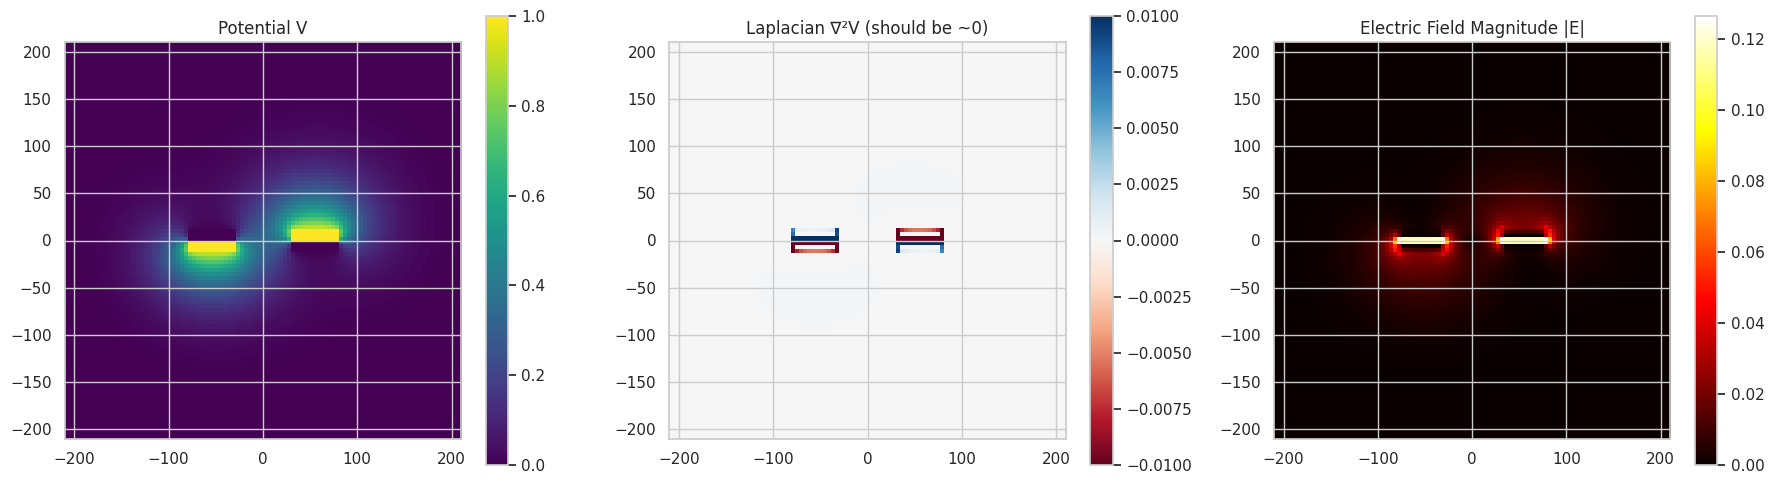

Uncomment the code above to run physics validation on a single trap.


In [10]:
# =========================
# Example: Validate a Single Trap
# =========================
# Uncomment and run this to test physics on one trap

# Build and solve trap (a) for testing
nx, ny = 100, 100
trap_builder = build_trap_d_algaas

# Create grid
x_temp = np.linspace(-500, 500, 10)
y_temp = np.linspace(-500, 500, 10)
X_temp, Y_temp = np.meshgrid(x_temp, y_temp)
electrodes_temp, ion_height = trap_builder(X_temp, Y_temp)

all_x = [e['cx'] for e in electrodes_temp]
all_y = [e['cy'] for e in electrodes_temp]
max_extent = max(max(np.abs(all_x)), max(np.abs(all_y)))
domain_size = max_extent * 2.0 + 100

x = np.linspace(-domain_size, domain_size, nx)
y = np.linspace(-domain_size, domain_size, ny)
X, Y = np.meshgrid(x, y)

electrodes, ion_height = trap_builder(X, Y)

V = np.zeros((ny, nx))
fixed = np.zeros_like(V, dtype=bool)

for e in electrodes:
    mask = create_rectangular_electrode_mask(e['cx'], e['cy'], e['width'], e['height'], X, Y)
    e['mask'] = mask
    V[mask] = e['voltage']
    fixed[mask] = True

V = solve_potential(nx, ny, electrodes, fixed, V, max_iter=3000, tol=1e-3)

# Run physics validation
results = run_all_physics_checks(V, X, Y, electrodes)

# Visualize the Laplacian (should be ~0 everywhere except boundaries)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(V, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='viridis')
axes[0].set_title('Potential V')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(results['laplacian'], extent=[X.min(), X.max(), Y.min(), Y.max()], 
                      origin='lower', cmap='RdBu', vmin=-0.01, vmax=0.01)
axes[1].set_title('Laplacian ∇²V (should be ~0)')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(results['E_mag'], extent=[X.min(), X.max(), Y.min(), Y.max()], 
                      origin='lower', cmap='hot')
axes[2].set_title('Electric Field Magnitude |E|')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

print("Uncomment the code above to run physics validation on a single trap.")


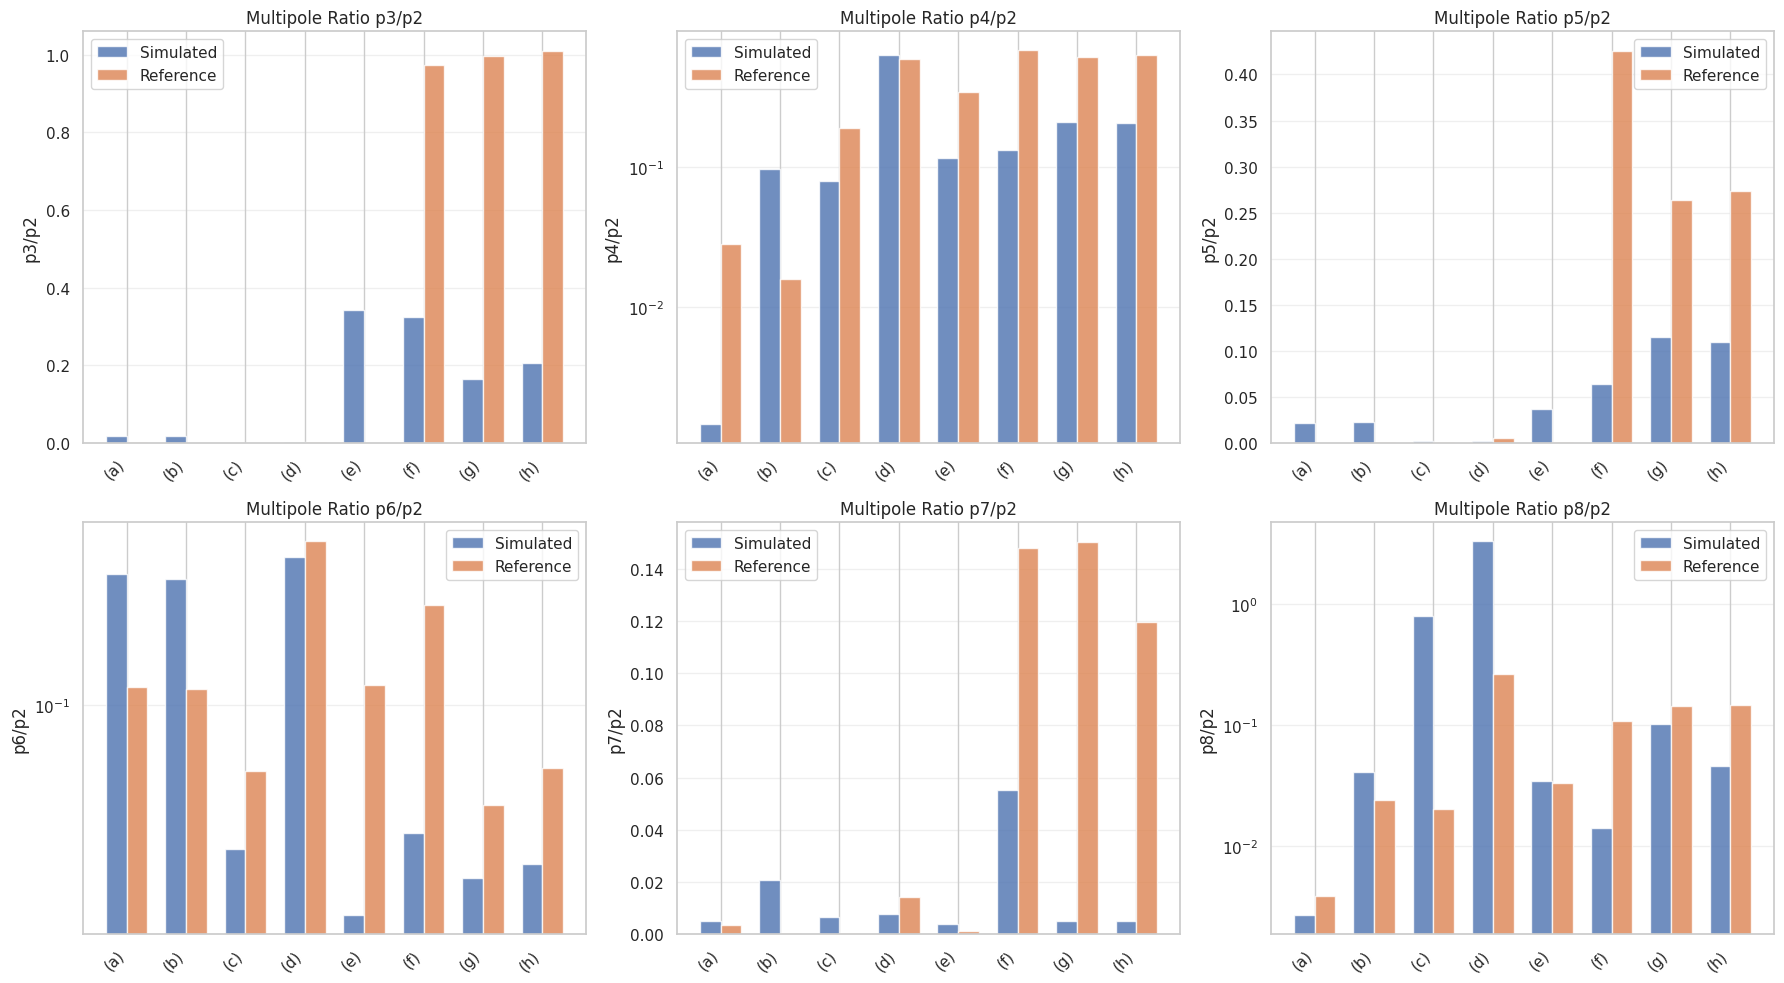

Comparison plot saved to: multipole_comparison.png


In [11]:
# =========================
# Visualization: Comparison Bar Chart
# =========================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

orders = [3, 4, 5, 6, 7, 8]

for idx, n in enumerate(orders):
    ax = axes[idx]
    col = f"p{n}/p2"
    
    # Extract data
    sim_values = results_df[col].values
    ref_values = reference_df[col].values
    
    x = np.arange(len(results_df))
    width = 0.35
    
    ax.bar(x - width/2, sim_values, width, label='Simulated', alpha=0.8)
    ax.bar(x + width/2, ref_values, width, label='Reference', alpha=0.8)
    
    ax.set_ylabel(f'p{n}/p2')
    ax.set_title(f'Multipole Ratio p{n}/p2')
    ax.set_xticks(x)
    ax.set_xticklabels([s.split()[0] for s in results_df.index], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Log scale for better visualization if needed
    if n in [4, 6, 8]:
        ax.set_yscale('log')

plt.tight_layout()
plt.savefig('multipole_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Comparison plot saved to: multipole_comparison.png")
